
# PAM example: transmission using frequency upconversion

This notebook is a Python/NumPy/SciPy implementation of the MATLAB example
`ak_pamSimple.m`.

The signal chain is kept close to the MATLAB version:

**PAM symbols → pulse shaping → frequency upconversion → passband channel → AWGN → equalization → downconversion → receiver low-pass filter → synchronization → PAM detection**

The notebook is deliberately split into small, independently understandable cells so that
each stage can be inspected and debugged.



## 1. Imports

The implementation uses:

- **NumPy** for numerical arrays and random symbols/noise
- **SciPy Signal** for filters, impulse responses, frequency responses and group delay
- **Matplotlib** for the optional diagnostic plots


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from scipy import signal

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("NumPy:", np.__version__)


NumPy: 1.26.4



## 2. Simulation parameters

These are the parameters that correspond directly to the MATLAB section
`Parameters to be changed / tuned`.

A fixed random seed is used so that results are reproducible from one notebook run
to another. Set `RANDOM_SEED = None` if a different random realization is desired.


In [2]:

# Parameters to be changed / tuned
M = 8                       # Number of PAM constellation symbols
Fs = 20_000                 # Sampling frequency [Hz]
L = 80                      # Samples per symbol (oversampling factor)
S = 100                     # Number of transmitted symbols
channelNumber = 1           # 0, 1, 2, or 3
showPlots = True             # Show diagnostic plots
Nequ = 40                   # Equalizer impulse-response length/order parameter
verify_ISI_atTx = True       # Check transmitter ISI
useCorrelationForSync = True # Use cross-correlation for synchronization

# Reproducibility
RANDOM_SEED = 12345
rng = np.random.default_rng(RANDOM_SEED)

# Fixed parameters from the MATLAB example
Fc1 = 3_000                 # Lower channel passband edge [Hz]
Fc2 = 3_800                 # Upper channel passband edge [Hz]
BW = Fc2 - Fc1              # Approximate channel bandwidth [Hz]
Fc = Fc1 + BW / 2           # Carrier frequency [Hz]
wc = 2 * np.pi * Fc / Fs    # Carrier frequency in rad/sample

print(f"Carrier frequency: {Fc:.1f} Hz")
print(f"Channel bandwidth: {BW:.1f} Hz")
print(f"Symbol rate: {Fs / L:.1f} baud")
print(f"Bit rate: {Fs / L * np.log2(M):.1f} bit/s")


Carrier frequency: 3400.0 Hz
Channel bandwidth: 800.0 Hz
Symbol rate: 250.0 baud
Bit rate: 750.0 bit/s



## 3. MATLAB-compatible helper functions

Here the channel generation, minimum-phase conversion and PAM demodulator are
separate functions.

One important Python/SciPy difference is that `scipy.signal.group_delay()` returns

```text
(w, group_delay)
```

The helper below also provides a MATLAB-like limited cross-correlation.

In [3]:

def force_stable_minimum_phase(b, tol=0.1):
    """Move FIR zeros inside the unit circle, following the MATLAB helper idea."""
    b = np.asarray(b, dtype=float).ravel()

    if len(b) <= 1:
        return b.copy()

    roots = np.roots(b)

    # Reflect zeros outside the unit circle into the unit circle.
    outside = np.abs(roots) > 1
    roots[outside] = 1 / np.conj(roots[outside])

    # Pull zeros that are numerically on the unit circle slightly inward.
    on_circle = np.abs(np.abs(roots) - 1) < tol
    roots[on_circle] = (1 - tol) * np.exp(1j * np.angle(roots[on_circle]))

    b_min = np.poly(roots)

    # Preserve the original FIR energy.
    denom = np.sum(np.abs(b_min) ** 2)
    if denom > 0:
        b_min *= np.sqrt(np.sum(b ** 2) / denom)

    return np.real_if_close(b_min).astype(float)


def get_channel(channel_number, Fs, Fc1, Fc2, wc):
    """Return numerator B(z) and denominator A(z) for the four MATLAB channels."""

    if channel_number == 0:
        # Ideal channel.
        b = np.array([1.0])
        a = np.array([1.0])

    elif channel_number == 1:
        # 2nd-order Butterworth bandpass.
        b, a = signal.butter(
            2,
            [Fc1, Fc2],
            btype="bandpass",
            fs=Fs,
        )

    elif channel_number == 2:
        # 4th-order elliptic bandpass.
        b, a = signal.ellip(
            4,
            2,       # Passband ripple [dB]
            40,      # Stopband attenuation [dB]
            [Fc1, Fc2],
            btype="bandpass",
            fs=Fs,
        )

    elif channel_number == 3:
        # FIR channel used in the MATLAB example.
        Mc = 14

        if Mc % 2 == 1:
            h = np.log(np.arange(2, Mc // 2 + 3)) / np.log(Mc // 2 + 2)
            h = np.concatenate([h, h[::-1]])
        else:
            h = np.log(np.arange(2, Mc // 2 + 2)) / np.log(Mc / 2 + 1)
            h = np.concatenate([h, np.array([1.0]), h[::-1]])

        b = h * np.cos(wc * np.arange(len(h)))
        a = np.array([1.0])

    else:
        raise ValueError("channelNumber must be 0, 1, 2, or 3.")

    return np.asarray(b, dtype=float), np.asarray(a, dtype=float)


def pam_demodulate(x, M):
    """Nearest-neighbor hard decision for an odd-symmetric M-PAM constellation."""
    x = np.asarray(x, dtype=float)

    constellation = np.arange(-(M - 1), M, 2)

    # Find the nearest constellation point.
    indices = np.argmin(np.abs(x[:, None] - constellation[None, :]), axis=1)
    x_hat = constellation[indices]

    return indices, x_hat


def xcorr_limited(x, y, max_lag):
    """MATLAB-like xcorr(x, y, max_lag), returning correlation and lags."""
    x = np.asarray(x)
    y = np.asarray(y)

    # np.correlate(x, y, 'full') uses the same basic cross-correlation
    # convention needed here.
    r_full = np.correlate(x, y, mode="full")
    lags_full = np.arange(-(len(y) - 1), len(x))

    keep = np.abs(lags_full) <= max_lag

    return r_full[keep], lags_full[keep]


def passband_mean_group_delay(b, a, f_low, f_high, n_points=500):
    """Estimate mean group delay over a passband in samples."""
    # scipy.signal.group_delay expects angular frequency in rad/sample when
    # the frequency vector is supplied explicitly.
    w = np.linspace(0, np.pi, n_points)

    # IMPORTANT: scipy returns (w, gd), not (gd, w).
    w_out, gd = signal.group_delay((b, a), w=w)

    band = (w_out >= 2 * np.pi * f_low / Fs) & (w_out <= 2 * np.pi * f_high / Fs)

    if not np.any(band):
        raise RuntimeError(
            "The requested passband was not represented in the group-delay grid."
        )

    gd_band = gd[band]

    # Group delay can become numerically unreliable close to zeros/poles.
    # Keep only finite values before averaging.
    gd_band = gd_band[np.isfinite(gd_band)]

    if gd_band.size == 0:
        raise RuntimeError("No finite group-delay samples were found in the passband.")

    return int(np.round(np.mean(gd_band))), w_out, gd


## 4. Generate the passband channel

In [4]:

# Generate the channel.
B_channel, A_channel = get_channel(
    channelNumber, Fs, Fc1, Fc2, wc
)

# The MATLAB example explicitly makes the channel minimum phase
# before constructing the equalizer.
B_channel = force_stable_minimum_phase(B_channel, tol=0.1)

print("Channel numerator length :", len(B_channel))
print("Channel denominator length:", len(A_channel))
print("B_channel =", np.round(B_channel, 6))
print("A_channel =", np.round(A_channel, 6))


Channel numerator length : 5
Channel denominator length: 5
B_channel = [ 0.016251 -0.       -0.026326  0.        0.010662]
A_channel = [ 1.       -1.771143  2.436971 -1.480665  0.700897]



## 5. Channel and equalizer impulse responses

MATLAB uses:

```matlab
h = impz(B_channel, A_channel, 400);
h_equalizer = impz(A_channel, B_channel, Nequ+1);
```

The Python version must therefore use **400 samples for the channel** but only
`Nequ + 1` samples for the equalizer. The previous notebook incorrectly generated
400 equalizer samples regardless of `Nequ`.


In [5]:

# Channel impulse response: MATLAB impz(B, A, 400)
_, h = signal.dimpulse((B_channel, A_channel, 1.0), n=400)
h = np.asarray(h[0]).squeeze()

# Equalizer impulse response: MATLAB impz(A, B, Nequ + 1)
_, h_equalizer = signal.dimpulse(
    (A_channel, B_channel, 1.0),
    n=Nequ + 1,
)
h_equalizer = np.asarray(h_equalizer[0]).squeeze()

print(f"Channel impulse response length   = {len(h)}")
print(f"Equalizer impulse response length = {len(h_equalizer)}")


Channel impulse response length   = 400
Equalizer impulse response length = 41


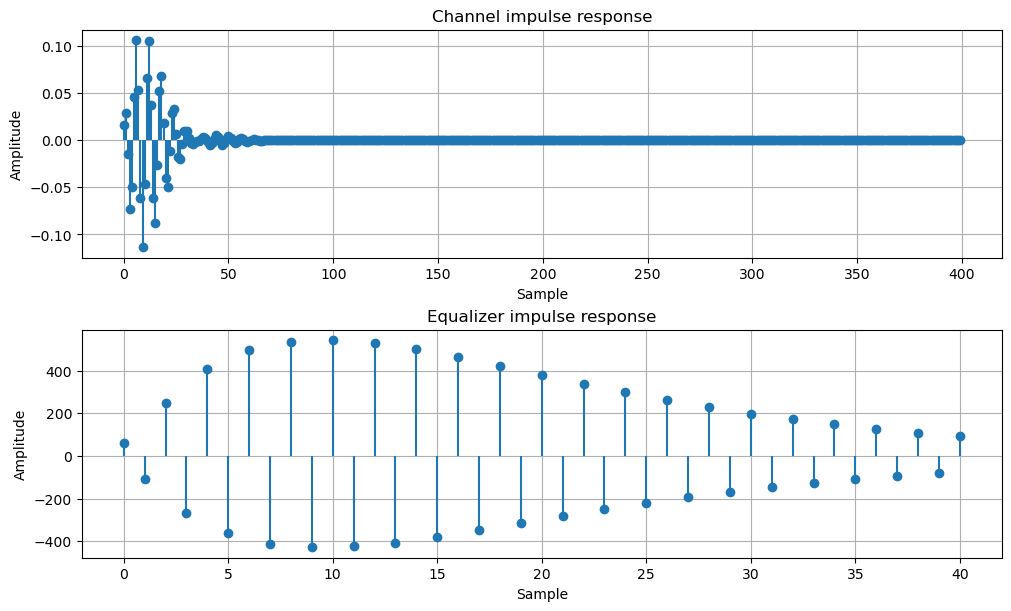

In [6]:

# Visualize the impulse responses.
fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

axes[0].stem(np.arange(len(h)), h, basefmt=" ")
axes[0].set_title("Channel impulse response")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")

axes[1].stem(np.arange(len(h_equalizer)), h_equalizer, basefmt=" ")
axes[1].set_title("Equalizer impulse response")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Amplitude")

plt.show()


## 6. Transmit pulse-shaping filter

In [7]:

# MATLAB:
# p = transpose(fir1(L, (BW/20)/Fs));
#
# fir1() uses a normalized cutoff where 1 corresponds to the Nyquist frequency.
# In SciPy, using fs=Fs allows us to specify the cutoff directly in Hz.
p = signal.firwin(
    L + 1,
    BW / 20,
    fs=Fs,
    pass_zero=True,
)

# MATLAB assumes an odd number of coefficients and places the cursor at:
# round((length(p)+1)/2)
cursorIndex_matlab = int(np.round((len(p) + 1) / 2))

# Convert the MATLAB 1-based index to Python's 0-based index.
cursorIndex = cursorIndex_matlab - 1

# The cursor sample is also the pulse-shaping filter delay.
delayInSamples = cursorIndex_matlab

# Scale the pulse so that the cursor equals exactly 1.
scalingFactor = 1.0 / p[cursorIndex]
p *= scalingFactor

print(f"Pulse length       = {len(p)} samples")
print(f"Cursor (MATLAB)    = {cursorIndex_matlab}")
print(f"Cursor amplitude   = {p[cursorIndex]:.6f}")
print(f"Initial delay      = {delayInSamples} samples")


Pulse length       = 81 samples
Cursor (MATLAB)    = 41
Cursor amplitude   = 1.000000
Initial delay      = 41 samples


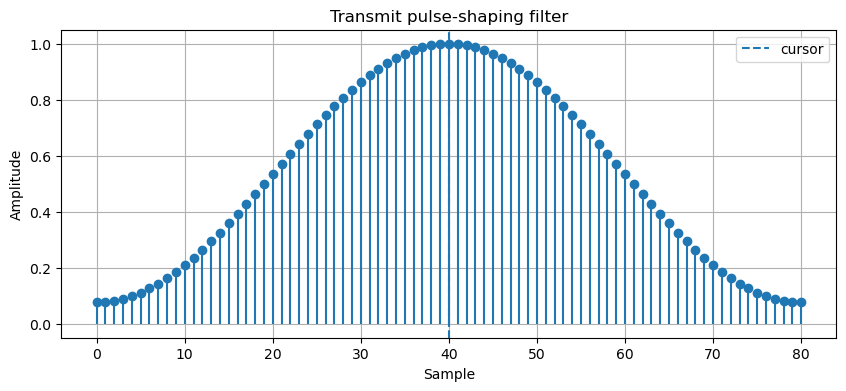

In [8]:

plt.figure(figsize=(10, 4))
plt.stem(np.arange(len(p)), p, basefmt=" ")
plt.axvline(cursorIndex, linestyle="--", label="cursor")
plt.title("Transmit pulse-shaping filter")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


## 7. Generate random M-PAM symbols

In [9]:

# MATLAB:
# constellat = -(M-1):2:M-1;
# ind = floor(M*rand(S,1));
# pamSymbols = transpose(constellat(ind+1));

constellat = np.arange(-(M - 1), M, 2)

# randint(0, M) is equivalent to floor(M * rand(...)).
ind = rng.integers(0, M, size=S)

pamSymbols = constellat[ind]

print("PAM constellation:", constellat)
print("First 20 transmitted symbols:", pamSymbols[:20])


PAM constellation: [-7 -5 -3 -1  1  3  5  7]
First 20 transmitted symbols: [ 3 -5  5 -3 -5  5  3  3  7 -1  5 -3  1  1 -5 -5 -5  3  1  7]


In [10]:

# Upsampling by L: insert L-1 zeros between consecutive PAM symbols.
x = np.zeros(S * L)
x[0::L] = pamSymbols

# Pulse shaping.
xp = np.convolve(x, p)

print(f"Upsampled signal length = {len(x)}")
print(f"Pulse-shaped signal length = {len(xp)}")


Upsampled signal length = 8000
Pulse-shaped signal length = 8080


## 8. Verify ISI at the transmitter

In [11]:

if verify_ISI_atTx:
    # MATLAB uses:
    # zz = xp(delayInSamples:L:end);
    #
    # MATLAB's first index is 1, so Python starts at delayInSamples - 1.
    zz = xp[delayInSamples - 1::L]

    isi_error = zz[:S] - pamSymbols
    isi_power = np.mean(isi_error ** 2)

    print(f"Power of ISI at Tx (should be zero) = {isi_power:.6e} W")


Power of ISI at Tx (should be zero) = 0.000000e+00 W


## 9. Frequency upconversion

In [12]:

# Generate a cosine carrier at the transmitter.
n = np.arange(len(xp))
carrier_tx = np.cos(wc * n)

# Upconvert the baseband PAM signal to the passband.
s = xp * carrier_tx

print(f"Carrier frequency = {Fc:.1f} Hz")
print(f"Transmitted signal length = {len(s)} samples")


Carrier frequency = 3400.0 Hz
Transmitted signal length = 8080 samples


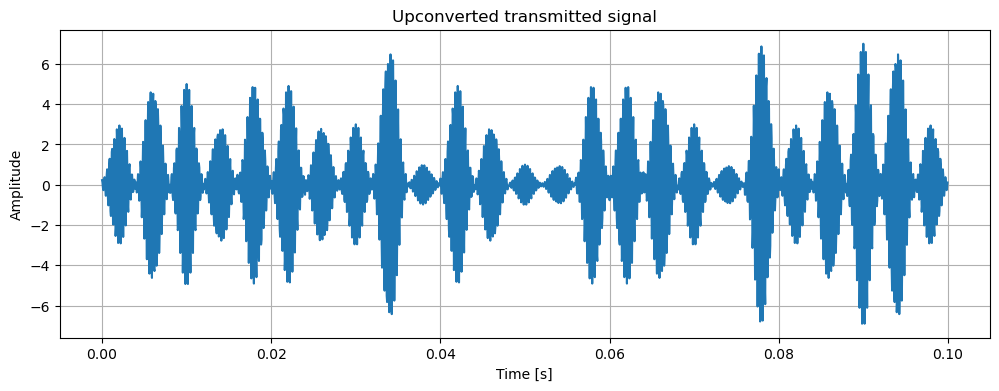

In [13]:

# Plot a short portion of the transmitted signal.
n_plot = min(2000, len(s))

plt.figure(figsize=(12, 4))
plt.plot(np.arange(n_plot) / Fs, s[:n_plot])
plt.title("Upconverted transmitted signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.show()


## 10. Pass the signal through the channel

In [14]:

# Channel filtering.
z = np.convolve(s, h)

print(f"Received signal before noise length = {len(z)} samples")


Received signal before noise length = 8479 samples



### Channel group delay

In SciPy:

```python
w, gd = signal.group_delay(...)
```

In [15]:

channelDelayInSamples, w_channel, gd_channel = passband_mean_group_delay(
    B_channel,
    A_channel,
    Fc1,
    Fc2,
)

delayInSamples += channelDelayInSamples

print(f"Estimated channel delay = {channelDelayInSamples} samples")
print(f"Accumulated delay       = {delayInSamples} samples")


Estimated channel delay = 12 samples
Accumulated delay       = 53 samples


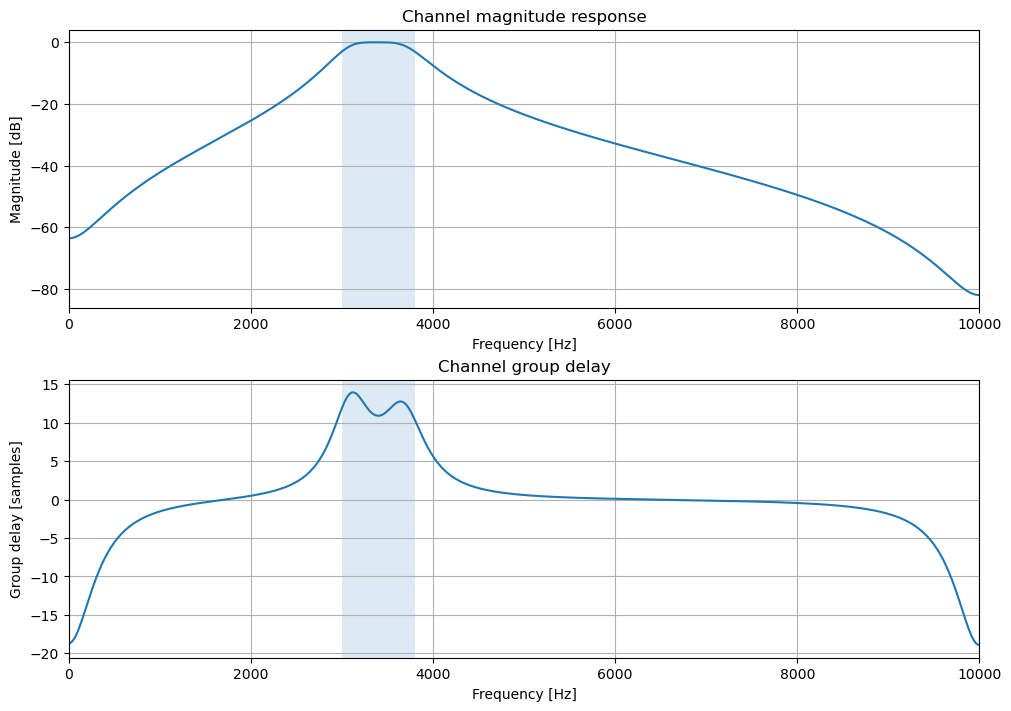

In [16]:
# Plot channel magnitude response and group delay.
# Use the same frequency grid for each quantity being plotted.
freq_channel, H_channel = signal.freqz(
    B_channel, A_channel, worN=2048, fs=Fs
)
freq_gd_channel = w_channel * Fs / (2 * np.pi)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)

axes[0].plot(
    freq_channel,
    20 * np.log10(np.maximum(np.abs(H_channel), 1e-12))
)
axes[0].axvspan(Fc1, Fc2, alpha=0.15)
axes[0].set_xlim(0, Fs / 2)
axes[0].set_title("Channel magnitude response")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("Magnitude [dB]")

axes[1].plot(freq_gd_channel, gd_channel)
axes[1].axvspan(Fc1, Fc2, alpha=0.15)
axes[1].set_xlim(0, Fs / 2)
axes[1].set_title("Channel group delay")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Group delay [samples]")

plt.show()


## 11. Add AWGN

In [17]:

SNRdB = 50
SNR = 10 ** (SNRdB / 10)

powerRxSignal = np.mean(np.abs(z) ** 2)
noisePower = powerRxSignal / SNR

noise = np.sqrt(noisePower) * rng.standard_normal(z.shape)
r = z + noise

print(f"Desired SNR     = {SNRdB:.1f} dB")
print(f"Signal power    = {powerRxSignal:.6e}")
print(f"Noise power     = {noisePower:.6e}")


Desired SNR     = 50.0 dB
Signal power    = 3.446043e+00
Noise power     = 3.446043e-05


## 12. Equalization

In [18]:

# Equalize the received signal.
r_eq = np.convolve(r, h_equalizer)

# Estimate equalizer group delay over the passband.
equalizerDelayInSamples, w_eq, gd_eq = passband_mean_group_delay(
    A_channel,
    B_channel,
    Fc1,
    Fc2,
)

delayInSamples += equalizerDelayInSamples

print(f"Estimated equalizer delay = {equalizerDelayInSamples} samples")
print(f"Accumulated delay         = {delayInSamples} samples")


Estimated equalizer delay = -12 samples
Accumulated delay         = 41 samples


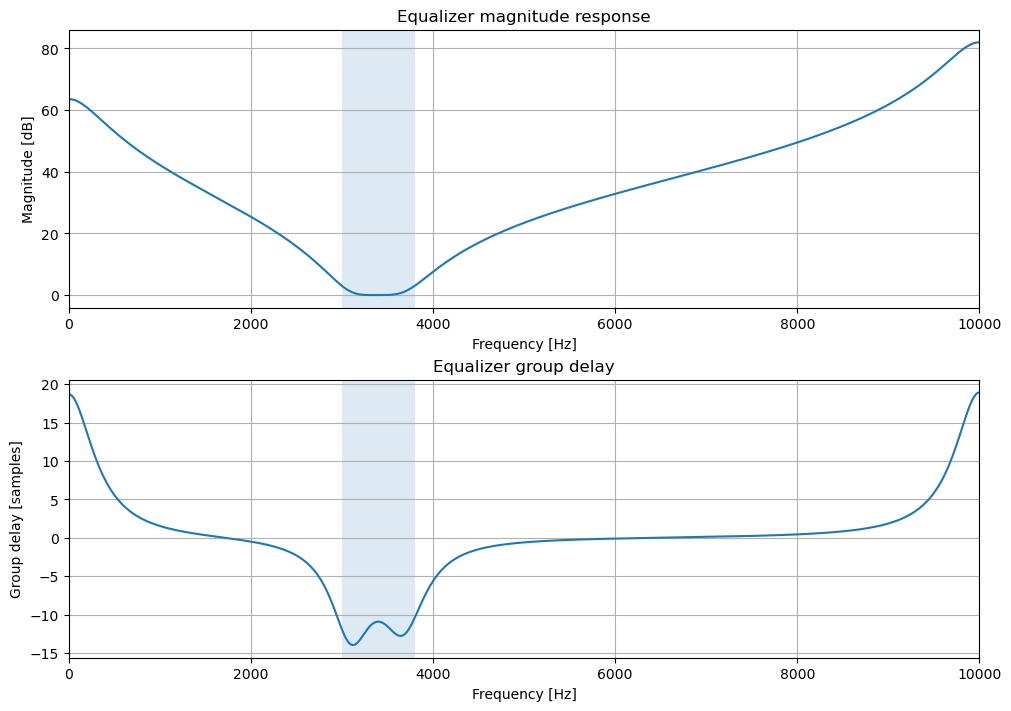

In [19]:
# Plot equalizer magnitude response and group delay.
freq_eq, H_eq = signal.freqz(
    A_channel, B_channel, worN=2048, fs=Fs
)
freq_gd_eq = w_eq * Fs / (2 * np.pi)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)

axes[0].plot(
    freq_eq,
    20 * np.log10(np.maximum(np.abs(H_eq), 1e-12))
)
axes[0].axvspan(Fc1, Fc2, alpha=0.15)
axes[0].set_xlim(0, Fs / 2)
axes[0].set_title("Equalizer magnitude response")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("Magnitude [dB]")

axes[1].plot(freq_gd_eq, gd_eq)
axes[1].axvspan(Fc1, Fc2, alpha=0.15)
axes[1].set_xlim(0, Fs / 2)
axes[1].set_title("Equalizer group delay")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Group delay [samples]")

plt.show()


## 13. Downconvert at the receiver

In [20]:

# Regenerate the synchronized cosine carrier at the receiver.
n_rx = np.arange(len(r_eq))
carrier_rx = np.cos(wc * n_rx)

# Multiplication produces the desired baseband component plus an image
# around twice the carrier frequency.
r2 = r_eq * carrier_rx

print(f"Downconverted signal length = {len(r2)} samples")


Downconverted signal length = 8519 samples


## 14. Receiver low-pass filter

The MATLAB example uses a 489th-order least-squares FIR filter:

```matlab
p_rx = firls(filterOrder,[0 BW/Fs BW/Fs 1],[1 1 0 0]);
```

MATLAB therefore produces **490 taps**.

SciPy's `signal.firls()` requires an **odd number of taps**, so it cannot directly
construct the 490-tap MATLAB filter. The notebook uses the nearest practical
SciPy equivalent: **491 taps (order 490)**. This also gives the same 245-sample
linear-phase delay used by the MATLAB `round((length(p_rx)-1)/2)` expression.

The normalized frequency specification is otherwise kept equivalent by using
`fs=2`, where 1 corresponds to the Nyquist frequency.


In [21]:
# MATLAB requests filter order 489, i.e. 490 taps.
#
# SciPy's firls() requires an ODD number of taps, so 490 taps is not allowed.
# The nearest equivalent with the same 245-sample linear-phase delay is
# therefore a 491-tap (order-490) FIR filter.
matlab_filterOrder = 489
filterOrder = 490

p_rx = signal.firls(
    filterOrder + 1,              # 491 taps; SciPy requires an odd number
    [0, BW / Fs, BW / Fs, 1],
    [1, 1, 0, 0],
    fs=2,
)

print(f"MATLAB receiver filter order = {matlab_filterOrder}")
print(f"SciPy receiver filter order  = {filterOrder}")
print(f"Receiver filter taps         = {len(p_rx)}")

# Filter the downconverted signal.
xphat = np.convolve(r2, p_rx)

# Linear-phase FIR delay.
receiver_filter_delay = (len(p_rx) - 1) // 2
delayInSamples += receiver_filter_delay

print(f"Receiver FIR delay     = {receiver_filter_delay} samples")
print(f"Total estimated delay  = {delayInSamples} samples")


MATLAB receiver filter order = 489
SciPy receiver filter order  = 490
Receiver filter taps         = 491
Receiver FIR delay     = 245 samples
Total estimated delay  = 286 samples


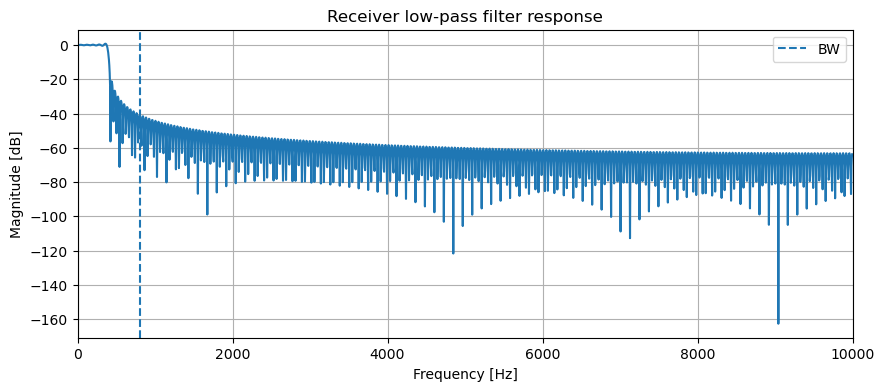

In [22]:

freq_rx, H_rx = signal.freqz(p_rx, worN=2048, fs=Fs)

plt.figure(figsize=(10, 4))
plt.plot(freq_rx, 20 * np.log10(np.maximum(np.abs(H_rx), 1e-12)))
plt.axvline(BW, linestyle="--", label="BW")
plt.xlim(0, Fs / 2)
plt.title("Receiver low-pass filter response")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.legend()
plt.show()


## 15. Synchronization

In [23]:

if useCorrelationForSync:
    # MATLAB:
    # [R,lags] = xcorr(xp,xphat,10*delayInSamples);
    #
    # The limited correlation avoids searching over the entire signal.
    R, lags = xcorr_limited(
        xp,
        xphat,
        max_lag=10 * delayInSamples,
    )

    maxLagIndex = np.argmax(np.abs(R))
    bestLag = lags[maxLagIndex]

    # MATLAB:
    # firstSymSample = abs(lags(maxLag)) + round(L/2);
    #
    # This expression is intentionally kept close to the original example.
    firstSymSample = abs(int(bestLag)) + int(np.round(L / 2))

    print(f"Correlation peak lag = {bestLag} samples")
else:
    firstSymSample = int(delayInSamples)

print(f"First symbol sample (MATLAB indexing) = {firstSymSample}")


Correlation peak lag = -297 samples
First symbol sample (MATLAB indexing) = 337


In [24]:

# Extract one sample every L samples.
#
# Convert MATLAB's 1-based firstSymSample to Python's 0-based slice index.
start = firstSymSample - 1

if start < 0 or start >= len(xphat):
    raise RuntimeError(
        f"Synchronization selected invalid sample {firstSymSample}. "
        f"Available signal length is {len(xphat)}."
    )

pamSymbolsRx = xphat[start::L][:S]

if len(pamSymbolsRx) < S:
    raise RuntimeError(
        f"Only {len(pamSymbolsRx)} received symbols were extracted; "
        f"{S} were expected. Check synchronization/delay."
    )

print(f"Extracted {len(pamSymbolsRx)} received symbols.")


Extracted 100 received symbols.


## 16. Normalize the received constellation

In [25]:

txConstellationPower = np.mean(constellat ** 2)
rxConstellationPower = np.mean(pamSymbolsRx ** 2)

if rxConstellationPower <= 0 or not np.isfinite(rxConstellationPower):
    raise RuntimeError("Invalid received constellation power.")

pamSymbolsRx = pamSymbolsRx * np.sqrt(
    txConstellationPower / rxConstellationPower
)

print(f"TX constellation power = {txConstellationPower:.6f}")
print(f"RX constellation power = {np.mean(pamSymbolsRx ** 2):.6f}")


TX constellation power = 21.000000
RX constellation power = 21.000000


## 17. PAM detection and performance metrics

In [26]:

chunksRx, r_hat = pam_demodulate(pamSymbolsRx, M)

# Symbol Error Rate, expressed as a percentage.
SER = 100 * np.mean(pamSymbols != r_hat)

# SNR before hard detection.
symError = pamSymbols - pamSymbolsRx
error_power_before = np.mean(symError ** 2)

if error_power_before == 0:
    SNRrx_before_detection = np.inf
else:
    SNRrx_before_detection = 10 * np.log10(
        np.mean(pamSymbols ** 2) / error_power_before
    )

# SNR after hard detection.
symError_detected = pamSymbols - r_hat
error_power_after = np.mean(symError_detected ** 2)

if error_power_after == 0:
    SNRrx_after_detection = np.inf
else:
    SNRrx_after_detection = 10 * np.log10(
        np.mean(pamSymbols ** 2) / error_power_after
    )

print(f"SER                      = {SER:.2f} %")
print(f"SNR before detection     = {SNRrx_before_detection:.2f} dB")
print(f"SNR after detection      = {SNRrx_after_detection:.2f} dB")


SER                      = 0.00 %
SNR before detection     = 25.70 dB
SNR after detection      = inf dB


In [27]:

# Display a compact comparison of transmitted and detected symbols.
comparison = np.column_stack([
    np.arange(S),
    pamSymbols,
    pamSymbolsRx,
    r_hat,
    pamSymbols != r_hat,
])

print("Columns: index, TX symbol, RX sample, detected symbol, error")
print(comparison[:20])


Columns: index, TX symbol, RX sample, detected symbol, error
[[ 0.          3.          3.15582288  3.          0.        ]
 [ 1.         -5.         -5.13322971 -5.          0.        ]
 [ 2.          5.          5.12099789  5.          0.        ]
 [ 3.         -3.         -3.22320927 -3.          0.        ]
 [ 4.         -5.         -5.15409815 -5.          0.        ]
 [ 5.          5.          5.09315128  5.          0.        ]
 [ 6.          3.          3.22868536  3.          0.        ]
 [ 7.          3.          3.20314319  3.          0.        ]
 [ 8.          7.          7.34290547  7.          0.        ]
 [ 9.         -1.         -1.0395094  -1.          0.        ]
 [10.          5.          5.17829242  5.          0.        ]
 [11.         -3.         -3.13908279 -3.          0.        ]
 [12.          1.          1.11465825  1.          0.        ]
 [13.          1.          0.98542527  1.          0.        ]
 [14.         -5.         -5.28575319 -5.          0.    

## 18. Achieved data rate

In [28]:

Rsym = Fs / L
Rbps = Rsym * np.log2(M)

print(f"Symbol rate = {Rsym:.1f} baud")
print(f"Bit rate    = {Rbps:.1f} bit/s")


Symbol rate = 250.0 baud
Bit rate    = 750.0 bit/s


## 19. Constellation

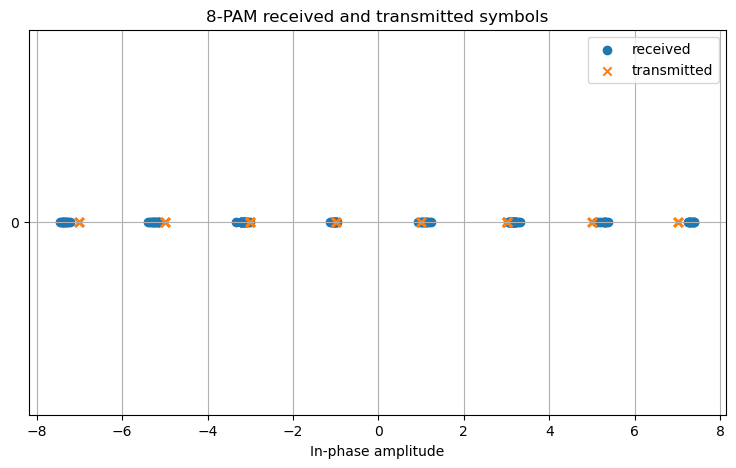

In [29]:

plt.figure(figsize=(9, 5))

# PAM is real-valued, so the imaginary axis is zero.
plt.scatter(
    pamSymbolsRx,
    np.zeros_like(pamSymbolsRx),
    marker="o",
    label="received",
)
plt.scatter(
    pamSymbols,
    np.zeros_like(pamSymbols),
    marker="x",
    label="transmitted",
)

plt.yticks([0], ["0"])
plt.xlabel("In-phase amplitude")
plt.title("8-PAM received and transmitted symbols")
plt.legend()
plt.show()


## 20. PSDs at the main stages

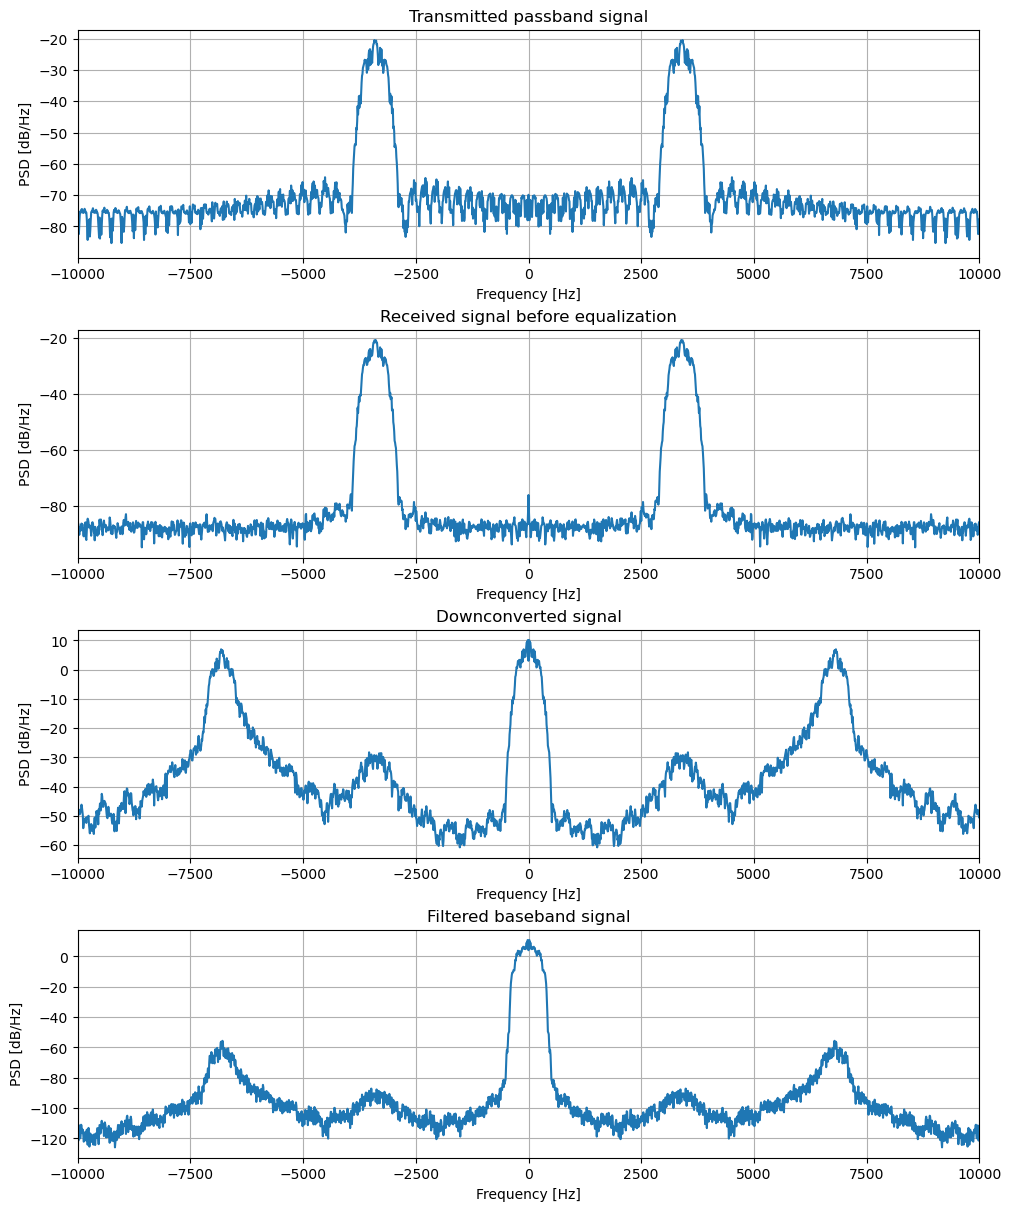

In [30]:

# A compact diagnostic view of the signal spectrum.
fig, axes = plt.subplots(4, 1, figsize=(10, 12), constrained_layout=True)

signals_for_psd = [
    (s, "Transmitted passband signal"),
    (r, "Received signal before equalization"),
    (r2, "Downconverted signal"),
    (xphat, "Filtered baseband signal"),
]

for ax, (sig, title) in zip(axes, signals_for_psd):
    f, Pxx = signal.welch(
        sig,
        fs=Fs,
        nperseg=min(2048, len(sig)),
        return_onesided=False,
    )

    # Shift the spectrum so negative frequencies appear on the left.
    f_shift = np.fft.fftshift(f)
    P_shift = np.fft.fftshift(Pxx)

    ax.plot(f_shift, 10 * np.log10(np.maximum(P_shift, 1e-20)))
    ax.set_title(title)
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("PSD [dB/Hz]")
    ax.set_xlim(-Fs / 2, Fs / 2)

plt.show()



## 21. Final summary

The notebook now mirrors the MATLAB processing stages while avoiding the main
problems in the original Python translation:

1. **SciPy `group_delay` output order is handled correctly:** `(w, gd)`.
2. **The passband is selected from the actual frequency vector**, preventing empty
   slices and `NaN` channel delays.
3. **The equalizer impulse response uses `Nequ + 1` samples**, matching MATLAB.
4. **MATLAB 1-based indexing is explicitly converted to Python 0-based indexing**
   where required.
5. **Receiver FIR design uses the MATLAB-equivalent normalized frequency convention.**
6. **Cross-correlation synchronization is isolated in its own function.**
7. **The simulation is split into small cells**, so intermediate signals, delays,
   filters and spectra can be inspected independently.
